In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm
tqdm.pandas(desc="Processing Rows")

/apps/common/software/Miniforge3/25.11.0-1-jupyter-base/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_id = "meta-llama/Llama-3.1-8B"
from transformers import AutoTokenizer, AutoModelForCausalLM

hf_token = "os.environ['HF_TOKEN']" 

tokenizer = AutoTokenizer.from_pretrained(model_id,token=hf_token)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=hf_token
)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [00:39<00:00,  7.31it/s]


In [4]:
# df = pd.read_csv('Named_Landforms_of_the_World.csv')
# df=df[['Bridges Full Name','Topographic','Continent']].drop_duplicates()
# df.head(50)

In [2]:

df=pd.read_csv("Datasets/World_Ecological_2015_Metadata.csv")
df

,Value,Count,Bio_Val,LF_Val,Lit_Val,GLC_Val,EF_Bio_Des,EF_LF_Desc,EF_Lit_Des,EF_GLC_Des,EF,ELU_Bio_De,ELU_LF_Des,ELU_Lit_De,ELU_GLC_De,ELU,Eco_Pot,ELU_Pot,ELU_Site
0,1,558780.0,1,1,4,210,Very Cold Wet,Flat or Nearly Flat Plains,Mixed Sedimentary Rock,Water bodies,Surface Water,Cold Wet,Plains,Mixed Sedimentary Rock,Surface Water,Surface Water,NaN,NaN,Cold Wet Plains
1,2,2457919.0,1,17,4,210,Very Cold Wet,Surface Water,Mixed Sedimentary Rock,Water bodies,Surface Water,Cold Wet,Surface Water,Mixed Sedimentary Rock,Surface Water,Surface Water,NaN,NaN,Cold Wet Surface Water
2,3,145694.0,2,1,4,210,Very Cold Very Wet,Flat or Nearly Flat Plains,Mixed Sedimentary Rock,Water bodies,Surface Water,Cold Wet,Plains,Mixed Sedimentary Rock,Surface Water,Surface Water,NaN,NaN,Cold Wet Plains
3,4,811247.0,1,1,4,220,Very Cold Wet,Flat or Nearly Flat Plains,Mixed Sedimentary Rock,Permanent snow and ice,Snow or Ice,Cold Wet,Plains,Mixed Sedimentary Rock,Permanent snow and ice,Snow or Ice,NaN,NaN,Cold Wet Plains
4,5,915300.0,2,1,4,220,Very Cold Very Wet,Flat or Nearly Flat Plains,Mixed Sedimentary Rock,Permanent snow and ice,Snow or Ice,Cold Wet,Plains,Mixed Sedimentary Rock,Permanent snow and ice,Snow or Ice,NaN,NaN,Cold Wet Plains
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106954,106955,6.0,1,9,5,50,Very Cold Wet,Scattered Low Mountains,Carbonate Sedimentary Rock,Broadleaved evergreen forest closed to open (>15%),Very Cold Wet Scattered Low Mountains on Carbonate Sedimentary Rock with Broadleaved evergreen forest closed to open (>15%),Cold Wet,Mountains,Carbonate Sedimentary Rock,Mostly Needleleaf/Evergreen Forest,Cold Wet Mountains on Carbonate Sedimentary Rock with Mostly Needleleaf/Evergreen Forest,NaN,NaN,Cold Wet Mountains
106955,106956,6.0,7,8,5,50,Cold Wet,High Hills,Carbonate Sedimentary Rock,Broadleaved evergreen forest closed to open (>15%),Cold Wet High Hills on Carbonate Sedimentary Rock with Broadleaved evergreen forest closed to open (>15%),Cold Wet,Hills,Carbonate Sedimentary Rock,Mostly Needleleaf/Evergreen Forest,Cold Wet Hills on Carbonate Sedimentary Rock with Mostly Needleleaf/Evergreen Forest,NaN,NaN,Cold Wet Hills
106956,106957,2.0,2,9,3,220,Very Cold Very Wet,Scattered Low Mountains,Pyroclastics,Permanent snow and ice,Snow or Ice,Cold Wet,Mountains,Pyroclastics,Permanent snow and ice,Snow or Ice,NaN,NaN,Cold Wet Mountains
106957,106958,1.0,2,11,14,40,Very Cold Very Wet,Scattered High Mountains,Unconsolidated Sediment,Mosaic vegetation (grassland/shrubland/forest) (>50%) / cropland (<50%),Very Cold Very Wet Scattered High Mountains on Unconsolidated Sediment with Mosaic vegetation (grassland/shrubland/forest) (>50%) / cropland (<50%),Cold Wet,Mountains,Unconsolidated Sediment,"Grassland, Scrub, or Shrub","Cold Wet Mountains on Unconsolidated Sediment with Grassland, Scrub, or Shrub",NaN,NaN,Cold Wet Mountains


In [6]:
df.columns

Index(['Value', 'Count', 'Bio_Val', 'LF_Val', 'Lit_Val', 'GLC_Val',
       'EF_Bio_Des', 'EF_LF_Desc', 'EF_Lit_Des', 'EF_GLC_Des', 'EF',
       'ELU_Bio_De', 'ELU_LF_Des', 'ELU_Lit_De', 'ELU_GLC_De', 'ELU',
       'Eco_Pot', 'ELU_Pot', 'ELU_Site'],
      dtype='object')

In [7]:
df_geo

,geonameid,name,asciiname,alternatenames,latitude,longitude,feature_class,feature_code,country_code,cc2,admin1,admin2,admin3,admin4,population,elevation,dem,timezone,modification_date
0,2994701,Roc Meler,Roc Meler,"Roc Mele,Roc Meler,Roc Mélé",42.58765,1.74180,T,PK,AD,"AD,FR",02,NaN,NaN,NaN,0,2811.0,2348,Europe/Andorra,2023-10-03
1,3017832,Pic de les Abelletes,Pic de les Abelletes,"Pic de la Font-Negre,Pic de la Font-Nègre,Pic de les Abelletes",42.52535,1.73343,T,PK,AD,FR,A9,66,663,66146,0,NaN,2411,Europe/Andorra,2014-11-05
2,3017833,Estany de les Abelletes,Estany de les Abelletes,"Estany de les Abelletes,Etang de Font-Negre,Étang de Font-Nègre",42.52915,1.73362,H,LK,AD,FR,A9,NaN,NaN,NaN,0,NaN,2260,Europe/Andorra,2014-11-05
3,3023203,Pic de Meners,Pic de Meners,NaN,42.62619,1.61763,T,PK,AD,NaN,02,NaN,NaN,NaN,0,2714.0,2541,Europe/Andorra,2026-05-09
4,3029315,Port de la Cabanette,Port de la Cabanette,"Port de la Cabanette,Porteille de la Cabanette",42.60000,1.73333,T,PASS,AD,"AD,FR",B3,09,091,09139,0,NaN,2379,Europe/Andorra,2014-11-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13434923,13587404,Sikuliaq Hill,Sikuliaq Hill,NaN,56.22400,-139.25300,U,HLLU,NaN,NaN,00,NaN,NaN,NaN,0,NaN,-9999,NaN,2026-02-12
13434924,13587405,Steamboat Lumps,Steamboat Lumps,NaN,28.20225,-84.72351,U,HLSU,NaN,NaN,00,NaN,NaN,NaN,0,NaN,-9999,NaN,2026-02-12
13434925,13587406,Viosca Knoll East,Viosca Knoll East,NaN,29.15972,-88.01510,U,KNLU,NaN,NaN,00,NaN,NaN,NaN,0,NaN,-9999,NaN,2026-02-12
13434926,13587407,Viosca Knoll West,Viosca Knoll West,NaN,29.08478,-88.38646,U,KNLU,NaN,NaN,00,NaN,NaN,NaN,0,NaN,-9999,NaN,2026-02-12


In [5]:

df=pd.read_csv("Datasets/World_Ecological_2015_Metadata.csv")
df
columns = [
    'geonameid', 'name', 'asciiname', 'alternatenames', 
    'latitude', 'longitude', 'feature_class', 'feature_code', 
    'country_code', 'cc2', 'admin1', 'admin2', 'admin3', 'admin4', 
    'population', 'elevation', 'dem', 'timezone', 'modification_date'
]

df_geo = pd.read_csv('Datasets/allCountries.txt', sep='\t', names=columns, low_memory=False)
df_geo
df_landforms = df_geo[df_geo['feature_class'] == 'T']
combined_dataset=pd.read_csv("Datasets/Global_Named_Landforms_With_Labels.csv")
combined_dataset=combined_dataset[['name','alternatenames','feature_code','ELU_LF_Des']]
combined_dataset

/localscratch/496762/ipykernel_3582504/1163499479.py:13: DtypeWarning: Columns (9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_dataset=pd.read_csv("Datasets/Global_Named_Landforms_With_Labels.csv")


,name,alternatenames,feature_code,ELU_LF_Des
0,Roc Meler,"Roc Mele,Roc Meler,Roc Mélé",PK,Mountains
1,Pic de les Abelletes,"Pic de la Font-Negre,Pic de la Font-Nègre,Pic de les Abelletes",PK,Mountains
2,Pic de Meners,NaN,PK,Mountains
3,Port de la Cabanette,"Port de la Cabanette,Porteille de la Cabanette",PASS,Mountains
4,Roc de Port Dret,NaN,PK,Mountains
...,...,...,...,...
1834956,Liverpool Bars,NaN,BAR,NaN
1834957,Doumeira Islands,Doumeira Islands,ISLS,NaN
1834958,Loaita Bank,"Bai Loai Ta,Bãi Loại Ta,Daoming Qunjiao,Loaita Bank,Luowan Dao,Nan-yueh T'ao,Nan-yüeh T’ao,Tao-ming Ch'un-chiao,Tao-ming Ch’un-chiao,dao ming qun jiao,luo wan dao,羅灣島,道明群礁",ATOL,NaN
1834959,Discovery Small Reef,"Burgos Reef,Da Nho,Discovery Small Reef,Dongnan Jiao,Hsiao-yen Chiao,Petit Recif Discovery,Petit Récif Discovery,Xiaofaxian Jiao,Xiaoxian Jiao,dong nan jiao,xiao fa xian jiao,xiao xian jiao,Đá Nhỏ,东南角,小现礁,小現礁,小發現礁",ATOL,NaN


In [7]:
exact_6_class_map = {
    # 1: Plains
    'PLN': 1, 'PLNS': 1, 'FLT': 1, 'PANS': 1,
    
    # 2: Hills and Low Tablelands
    'HLL': 2, 'HLLS': 2, 'MND': 2, 'KNOB': 2,
    
    # 3: High Tablelands
    'PT': 3, 'PLAT': 3, 'MESA': 3, 'BUTT': 3,
    
    # 4: Mountains
    'RDG': 4, 'RDGS': 4, 'SADL': 4, 'DUNE': 4,
    
    # 5: Widely Spaced Mountains
    'MT': 5, 'MTS': 5, 'PK': 5, 'PKS': 5, 'CONE': 5, 'VOLC': 5, 'NUP': 5, 'RK': 5,
    
    # 7: Depressions or Basins
    'BSN': 7, 'BSNS': 7, 'DPR': 7, 'SINK': 7, 'CRQS': 7, 'CRATER': 7
}

combined_dataset['macro_class_id'] = combined_dataset['feature_code'].map(exact_6_class_map)
combined_dataset = combined_dataset.dropna(subset=['macro_class_id'])
combined_dataset['macro_class_id'] = combined_dataset['macro_class_id'].astype(int)
combined_dataset

/localscratch/452998/ipykernel_2375141/2934771074.py:2: DtypeWarning: Columns (9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_dataset=pd.read_csv("Global_Named_Landforms_With_Labels.csv")


In [ ]:
combined_dataset=combined_dataset[~combined_dataset['macro_class_id'].isna()]
combined_dataset=combined_dataset[['name','macro_class_id']]
combined_dataset.columns=['Bridges Full Name','Topographic']
combined_dataset = combined_dataset.groupby('Bridges Full Name')['Topographic'].apply(lambda x: list(set(x))).reset_index()
ascii_mask = combined_dataset['Bridges Full Name'].astype(str).str.contains(r'^[\x00-\x7F]+$')
combined_dataset = combined_dataset[ascii_mask].reset_index(drop=True)
combined_dataset

In [8]:
combined_dataset=combined_dataset[['name','alternatenames','feature_code','ELU_LF_Des']]

In [9]:
combined_dataset['feature_code'].value_counts()

feature_code
HLL     502511
MT      423139
ISL     166962
VAL     140702
PT      112583
         ...  
PTS          7
CRQS         5
SLID         5
ASPH         2
PANS         1
Name: count, Length: 98, dtype: int64

In [10]:
exact_6_class_map = {
    # 1: Plains
    'PLN': 1, 'PLNS': 1, 'FLT': 1, 'PANS': 1,
    
    # 2: Hills and Low Tablelands
    'HLL': 2, 'HLLS': 2, 'MND': 2, 'KNOB': 2,
    
    # 3: High Tablelands
    'PT': 3, 'PLAT': 3, 'MESA': 3, 'BUTT': 3,
    
    # 4: Mountains
    'RDG': 4, 'RDGS': 4, 'SADL': 4, 'DUNE': 4,
    
    # 5: Widely Spaced Mountains
    'MT': 5, 'MTS': 5, 'PK': 5, 'PKS': 5, 'CONE': 5, 'VOLC': 5, 'NUP': 5, 'RK': 5,
    
    # 7: Depressions or Basins
    'BSN': 7, 'BSNS': 7, 'DPR': 7, 'SINK': 7, 'CRQS': 7, 'CRATER': 7
}
combined_dataset['macro_class_id'] = combined_dataset['feature_code'].map(exact_6_class_map)
combined_dataset = combined_dataset.dropna(subset=['macro_class_id'])
combined_dataset['macro_class_id'] = combined_dataset['macro_class_id'].astype(int)
combined_dataset

,name,alternatenames,feature_code,ELU_LF_Des,macro_class_id
0,Roc Meler,"Roc Mele,Roc Meler,Roc Mélé",PK,Mountains,5
1,Pic de les Abelletes,"Pic de la Font-Negre,Pic de la Font-Nègre,Pic de les Abelletes",PK,Mountains,5
2,Pic de Meners,NaN,PK,Mountains,5
4,Roc de Port Dret,NaN,PK,Mountains,5
6,Roc del Xeig,NaN,RK,Mountains,5
...,...,...,...,...,...
1834929,South Rock,"Danzhu,Danzhu Shi,Danzhushi,South Rock,Tan-chu Shih,dan zhu,dan zhu shi,单柱,单柱石",RK,NaN,5
1834942,Whale Rock (historical),NaN,RK,NaN,5
1834949,Echo Point - Three Sisters,NaN,MT,NaN,5
1834953,Ipil Hill,"Ipil Hill,Ipil Seamount",HLL,NaN,2


In [11]:
combined_dataset=combined_dataset[~combined_dataset['macro_class_id'].isna()]

In [12]:
combined_dataset=combined_dataset[['name','macro_class_id']]
combined_dataset.columns=['Bridges Full Name','Topographic']

In [13]:
# northamerica=df[df['Continent'].str.contains('North America|Island')]
# northamerica=northamerica[['Bridges Full Name','Topographic']].drop_duplicates()
# northamerica=northamerica.groupby("Bridges Full Name").agg({"Topographic":list}).reset_index()
# northamerica

In [14]:
# X_train=df[df['Continent'].str.contains('X_train|Africa|Asia|South America|Australia')]
# X_train=X_train.groupby("Bridges Full Name").agg({"Topographic":list}).reset_index()

# X_train

In [15]:
combined_dataset

,Bridges Full Name,Topographic
0,Roc Meler,5
1,Pic de les Abelletes,5
2,Pic de Meners,5
4,Roc de Port Dret,5
6,Roc del Xeig,5
...,...,...
1834929,South Rock,5
1834942,Whale Rock (historical),5
1834949,Echo Point - Three Sisters,5
1834953,Ipil Hill,2


In [16]:
combined_dataset = combined_dataset.groupby('Bridges Full Name')['Topographic'].apply(lambda x: list(set(x))).reset_index()

In [17]:
ascii_mask = combined_dataset['Bridges Full Name'].astype(str).str.contains(r'^[\x00-\x7F]+$')
combined_dataset = combined_dataset[ascii_mask].reset_index(drop=True)
combined_dataset

,Bridges Full Name,Topographic
0,'Adade Yus Mountain,[5]
1,'Aqabat Nikid,[5]
2,'Elb Chouf,[4]
3,'Elb ech Chaoufa,[4]
4,'S Airde Beinn,[2]
...,...,...
618599,wzgorze na Katarynkach,[2]
618600,wzgorze nad Tuchlinkiem,[2]
618601,yak Gawa,[5]
618602,ytre Midtberget,[2]


In [18]:
from sklearn.model_selection import StratifiedKFold

X = combined_dataset[['Bridges Full Name']]
y = combined_dataset['Topographic']

y_stratify = y.apply(lambda x: str(sorted(x)))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_stratify)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

/home/ravim/.local/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [19]:
# IMPORTANT:
# If you already imported torch in this notebook, restart the kernel first,
# then run this entire cell from the top.

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import torch
import numpy as np
from torch.utils.data import DataLoader
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, hamming_loss, accuracy_score
from tqdm import tqdm

mlb = MultiLabelBinarizer()

X_train_list = X_train["Bridges Full Name"].tolist()
X_test_list  = X_test["Bridges Full Name"].tolist()

y_train_scaled = mlb.fit_transform(y_train.tolist())
y_test_scaled  = mlb.transform(y_test.tolist())

BATCH_SIZE = 64          # try 64 on L40S; if CUDA OOM, change to 32
LAYERS = list(range(13, 32))
MAX_LEN = 64

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model.eval()
model.config.use_cache = False

if hasattr(model, "gradient_checkpointing_disable"):
    model.gradient_checkpointing_disable()

train_loader = DataLoader(
    X_train_list,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    X_test_list,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

def extract_all_layers_hooks_cpu(loader, desc):
    """
    Extracts last real token hidden state from selected layers.
    Stores activations on CPU immediately to avoid CUDA OOM.
    """

    layer_chunks = {l: [] for l in LAYERS}
    captured = {}

    def make_hook(l):
        def hook_fn(module, input, output):
            hs = output[0] if isinstance(output, tuple) else output
            captured[l] = hs.detach()
        return hook_fn

    handles = [
        model.model.layers[l].register_forward_hook(make_hook(l))
        for l in LAYERS
    ]

    try:
        with torch.inference_mode():
            for batch in tqdm(loader, desc=desc):
                inputs = tokenizer(
                    list(batch),
                    padding=True,
                    truncation=True,
                    max_length=MAX_LEN,
                    return_tensors="pt"
                ).to(model.device)

                lengths = inputs["attention_mask"].sum(dim=1) - 1
                batch_idx = torch.arange(inputs["input_ids"].shape[0], device=model.device)

                model(**inputs, use_cache=False)

                for l in LAYERS:
                    last_tok = captured[l][batch_idx, lengths, :]

                    # Move to CPU immediately; keep CPU cache compact.
                    layer_chunks[l].append(
                        last_tok.float().cpu().numpy().astype(np.float16)
                    )

                captured.clear()
                del inputs, lengths, batch_idx, last_tok
                torch.cuda.empty_cache()

    finally:
        for h in handles:
            h.remove()

    return {
        l: np.concatenate(layer_chunks[l], axis=0)
        for l in LAYERS
    }


print("Extracting train hidden states...")
train_cache = extract_all_layers_hooks_cpu(train_loader, "Train")

print("Extracting test hidden states...")
test_cache = extract_all_layers_hooks_cpu(test_loader, "Test")

torch.cuda.empty_cache()
gc.collect()



Extracting train hidden states...


Train: 100%|██████████| 7733/7733 [11:08<00:00, 11.57it/s]


Extracting test hidden states...


Test: 100%|██████████| 1934/1934 [02:44<00:00, 11.73it/s]


19

In [20]:
import gc
import time
import numpy as np
import torch

from sklearn.linear_model import SGDClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, hamming_loss, accuracy_score

subset_acc_list = []
hamming_loss_list = []
macro_f1_list = []
micro_f1_list = []

total_start = time.perf_counter()

for layer_idx in LAYERS:
    layer_start = time.perf_counter()

    print(f"\n--- Processing Layer {layer_idx} ---")
    gc.collect()
    torch.cuda.empty_cache()

    X_train_layer = np.ascontiguousarray(
        train_cache[layer_idx].astype(np.float32, copy=False)
    )
    X_test_layer = np.ascontiguousarray(
        test_cache[layer_idx].astype(np.float32, copy=False)
    )

    print("Train shape:", X_train_layer.shape)
    print("Test shape:", X_test_layer.shape)
    print("Labels:", y_train_scaled.shape[1])

    # logistic regression
    base_lr = SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=1e-4,
        max_iter=5,
        tol=1e-3,
        n_jobs=1,
        random_state=42,
        verbose=0
    )

    multi_label_model = MultiOutputClassifier(
        base_lr,
        n_jobs=1   
    )

    fit_start = time.perf_counter()
    multi_label_model.fit(X_train_layer, y_train_scaled)
    fit_time = time.perf_counter() - fit_start
    print(f"Fit time:     {fit_time:.2f} sec / {fit_time/60:.2f} min")

    pred_start = time.perf_counter()
    predictions = multi_label_model.predict(X_test_layer)
    pred_time = time.perf_counter() - pred_start
    print(f"Predict time: {pred_time:.2f} sec / {pred_time/60:.2f} min")

    metric_start = time.perf_counter()

    subset_acc = accuracy_score(y_test_scaled, predictions)
    ham_loss   = hamming_loss(y_test_scaled, predictions)
    macro_f1   = f1_score(y_test_scaled, predictions, average="macro", zero_division=0)
    micro_f1   = f1_score(y_test_scaled, predictions, average="micro", zero_division=0)

    metric_time = time.perf_counter() - metric_start

    subset_acc_list.append(subset_acc)
    hamming_loss_list.append(ham_loss)
    macro_f1_list.append(macro_f1)
    micro_f1_list.append(micro_f1)

    layer_time = time.perf_counter() - layer_start

    print(f"Metric time:  {metric_time:.2f} sec")
    print(f"Exact Match (Subset Acc): {subset_acc:.4f}")
    print(f"Hamming Loss (Error Rate): {ham_loss:.4f}")
    print(f"Macro F1 Score:           {macro_f1:.4f}")
    print(f"Micro F1 Score:           {micro_f1:.4f}")
    print(f"Total layer time:         {layer_time:.2f} sec / {layer_time/60:.2f} min")

    del X_train_layer
    del X_test_layer
    del predictions
    del multi_label_model
    del base_lr

    gc.collect()
    torch.cuda.empty_cache()

total_time = time.perf_counter() - total_start
print(f"\nTotal probe time: {total_time:.2f} sec / {total_time/60:.2f} min")


--- Processing Layer 13 ---
Train shape: (494884, 4096)
Test shape: (123720, 4096)
Labels: 6


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Fit time:     149.80 sec / 2.50 min
Predict time: 1.59 sec / 0.03 min
Metric time:  0.12 sec
Exact Match (Subset Acc): 0.6217
Hamming Loss (Error Rate): 0.0957
Macro F1 Score:           0.6864
Micro F1 Score:           0.7165
Total layer time:         158.17 sec / 2.64 min

--- Processing Layer 14 ---
Train shape: (494884, 4096)
Test shape: (123720, 4096)
Labels: 6


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Fit time:     150.65 sec / 2.51 min
Predict time: 1.58 sec / 0.03 min
Metric time:  0.10 sec
Exact Match (Subset Acc): 0.6283
Hamming Loss (Error Rate): 0.0940
Macro F1 Score:           0.6952
Micro F1 Score:           0.7210
Total layer time:         159.04 sec / 2.65 min

--- Processing Layer 15 ---
Train shape: (494884, 4096)
Test shape: (123720, 4096)
Labels: 6


...

Fit time:     151.00 sec / 2.52 min
Predict time: 1.58 sec / 0.03 min
Metric time:  0.10 sec
Exact Match (Subset Acc): 0.4229
Hamming Loss (Error Rate): 0.1509
Macro F1 Score:           0.5780
Micro F1 Score:           0.5404
Total layer time:         159.41 sec / 2.66 min

--- Processing Layer 30 ---
Train shape: (494884, 4096)
Test shape: (123720, 4096)
Labels: 6


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Fit time:     150.28 sec / 2.50 min
Predict time: 1.58 sec / 0.03 min
Metric time:  0.10 sec
Exact Match (Subset Acc): 0.4216
Hamming Loss (Error Rate): 0.1406
Macro F1 Score:           0.5917
Micro F1 Score:           0.5451
Total layer time:         158.69 sec / 2.64 min

--- Processing Layer 31 ---
Train shape: (494884, 4096)
Test shape: (123720, 4096)
Labels: 6


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Fit time:     147.14 sec / 2.45 min
Predict time: 1.58 sec / 0.03 min
Metric time:  0.10 sec
Exact Match (Subset Acc): 0.4930
Hamming Loss (Error Rate): 0.1284
Macro F1 Score:           0.6295
Micro F1 Score:           0.5984
Total layer time:         155.38 sec / 2.59 min

Total probe time: 3035.36 sec / 50.59 min


In [21]:
torch.cuda.empty_cache()

In [21]:
subset_acc_list = [
    0.0000, 0.4726, 0.5368, 0.5591, 0.5861, 0.5961, 0.6058, 0.6070,
    0.6158, 0.6198, 0.6184, 0.6212, 0.6227, 0.6217, 0.6283, 0.6358,
    0.6416, 0.6468, 0.6348, 0.6334, 0.6232, 0.5965, 0.5757, 0.5599,
    0.5387, 0.5159, 0.4979, 0.4825, 0.4700, 0.4229, 0.4216, 0.4930
]

hamming_loss_list = [
    0.1737, 0.1258, 0.1121, 0.1073, 0.1011, 0.0988, 0.0967, 0.0962,
    0.0943, 0.0934, 0.0935, 0.0931, 0.0928, 0.0957, 0.0940, 0.0929,
    0.0916, 0.0909, 0.0945, 0.0943, 0.0976, 0.1049, 0.1098, 0.1150,
    0.1235, 0.1322, 0.1328, 0.1403, 0.1441, 0.1509, 0.1406, 0.1284
]

macro_f1_list = [
    0.0000, 0.3673, 0.4375, 0.4764, 0.5538, 0.5819, 0.5596, 0.5815,
    0.5951, 0.6237, 0.6147, 0.6201, 0.6395, 0.6864, 0.6952, 0.7058,
    0.7172, 0.7218, 0.7180, 0.7196, 0.7138, 0.7001, 0.6897, 0.6808,
    0.6680, 0.6509, 0.6360, 0.6220, 0.6127, 0.5780, 0.5917, 0.6295
]

micro_f1_list = [
    0.0000, 0.5915, 0.6477, 0.6681, 0.6915, 0.6999, 0.7076, 0.7096,
    0.7169, 0.7204, 0.7197, 0.7215, 0.7229, 0.7165, 0.7210, 0.7232,
    0.7282, 0.7320, 0.7189, 0.7199, 0.7101, 0.6849, 0.6685, 0.6540,
    0.6335, 0.6122, 0.5980, 0.5863, 0.5727, 0.5404, 0.5451, 0.5984
]

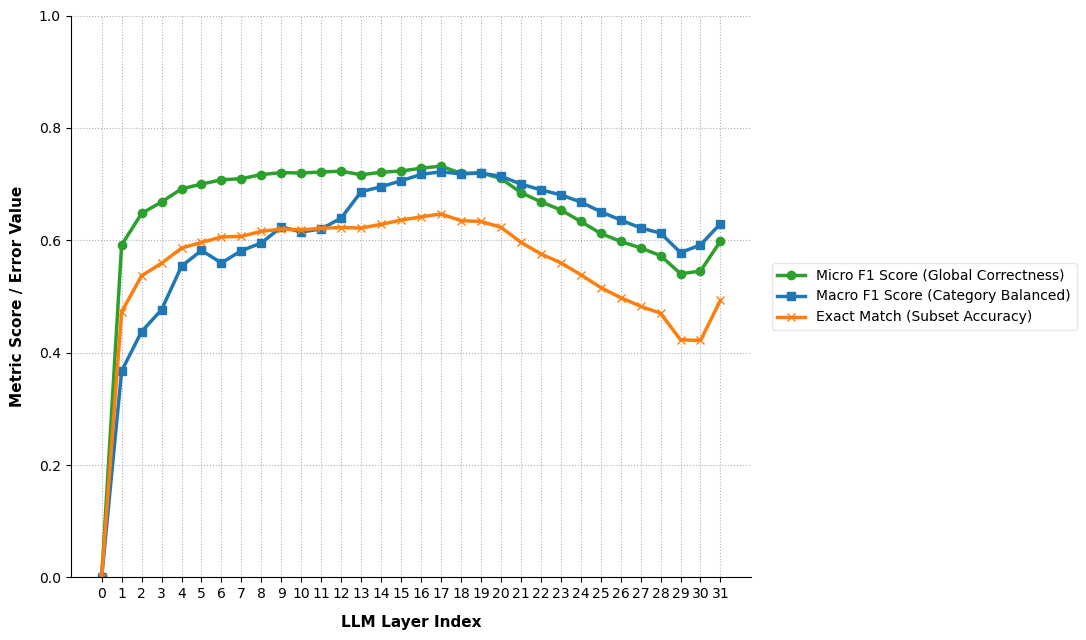

In [23]:
import matplotlib.pyplot as plt

layers = list(range(32))
subset_acc = subset_acc_list
hamming_loss = hamming_loss_list
macro_f1 = macro_f1_list
micro_f1=micro_f1_list

fig, ax = plt.subplots(figsize=(11, 6.5), dpi=100)

ax.plot(layers, micro_f1, label='Micro F1 Score (Global Correctness)', marker='o', linewidth=2.5, color='#2ca02c')
ax.plot(layers, macro_f1, label='Macro F1 Score (Category Balanced)', marker='s', linewidth=2.5, color='#1f77b4')
# ax.plot(layers, hamming_loss, label='Hamming Loss (Error Rate - Lower is Better)', marker='d', linewidth=2.5, color='#d62728', linestyle='--')
ax.plot(layers, subset_acc, label='Exact Match (Subset Accuracy)', marker='x', linewidth=2.5, color='#ff7f0e')

ax.set_xlabel('LLM Layer Index', fontsize=11, fontweight='semibold', labelpad=10)
ax.set_ylabel('Metric Score / Error Value', fontsize=11, fontweight='semibold', labelpad=10)
ax.set_xticks(layers)
ax.set_ylim(0.0, 1.0)

ax.grid(True, linestyle=':', alpha=0.6, color='gray')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, frameon=True, facecolor='white', edgecolor='#e0e0e0')

plt.tight_layout()
# plt.savefig("llama8b.png")
plt.show()